In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.tree import export_graphviz
import graphviz

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Curso completo inteligencia artificial/3.Algoritmos de Machine Learning/insurance.csv',
keep_default_na=False,
index_col=None
)
base.head()
print(base.shape)

Mounted at /content/drive
(20000, 28)


In [ ]:
base = base.drop(columns=['Unnamed: 0'])
base.head()

,GoodStudent,Age,SocioEcon,RiskAversion,VehicleYear,ThisCarDam,RuggedAuto,Accident,MakeModel,DrivQuality,...,HomeBase,AntiTheft,PropCost,OtherCarCost,OtherCar,MedCost,Cushioning,Airbag,ILiCost,DrivHist
0,False,Adult,Prole,Adventurous,Older,Moderate,EggShell,Mild,Economy,Poor,...,City,False,TenThou,Thousand,True,Thousand,Poor,False,Thousand,Many
1,False,Senior,Prole,Cautious,Current,None,Football,None,Economy,Normal,...,City,True,Thousand,Thousand,True,Thousand,Good,True,Thousand,Zero
2,False,Senior,UpperMiddle,Psychopath,Current,None,Football,None,FamilySedan,Excellent,...,City,False,Thousand,Thousand,False,Thousand,Good,True,Thousand,One
3,False,Adolescent,Middle,Normal,Older,None,EggShell,None,Economy,Normal,...,Suburb,False,Thousand,Thousand,True,Thousand,Fair,False,Thousand,Zero
4,False,Adolescent,Prole,Normal,Older,Moderate,Football,Moderate,Economy,Poor,...,City,False,TenThou,Thousand,False,Thousand,Fair,False,Thousand,Many


In [ ]:
y = base.iloc[:,7].values
X  = base.drop(base.columns[7], axis=1).values
X

array([[False, 'Adult', 'Prole', ..., False, 'Thousand', 'Many'],
       [False, 'Senior', 'Prole', ..., True, 'Thousand', 'Zero'],
       [False, 'Senior', 'UpperMiddle', ..., True, 'Thousand', 'One'],
       ...,
       [False, 'Senior', 'UpperMiddle', ..., True, 'Thousand', 'Zero'],
       [False, 'Adult', 'Middle', ..., True, 'Thousand', 'Zero'],
       [False, 'Adult', 'Middle', ..., True, 'Thousand', 'Zero']],
      dtype=object)

In [ ]:
labelencoder = LabelEncoder()
for i in range(X.shape[1]):
  if X[:,i].dtype == 'object':
    X[:,i] = labelencoder.fit_transform(X[:,i])

In [ ]:
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(X,y,test_size=0.3, random_state=12)

In [ ]:
modelo = DecisionTreeClassifier(random_state=1,max_depth=8, max_leaf_nodes=6)
modelo.fit(X_treinamento,y_treinamento)

DecisionTreeClassifier(max_depth=8, max_leaf_nodes=6, random_state=1)

In [ ]:
dot_data = export_graphviz(modelo, out_file=None, filled=True, feature_names=base.columns[:-1],
                           class_names=True, rounded=True)
graph = graphviz.Source(dot_data)
graph.render("decision_tree",format="png")
graph.view()

'decision_tree.pdf'

In [ ]:
previsoes = modelo.predict(X_teste)

In [ ]:
previsoes

array(['Moderate', 'Mild', 'Severe', ..., 'None', 'Mild', 'None'],
      dtype=object)

In [ ]:
accuracy = accuracy_score(y_teste,previsoes)
precision = precision_score(y_teste, previsoes, average='weighted')
recall = recall_score(y_teste, previsoes, average='weighted')
f1 = f1_score(y_teste, previsoes, average='weighted')
print(f'Acurácia: {accuracy}, Precisão: {precision}, Recall: {recall}, F1: {f1}')

Acurácia: 0.9375, Precisão: 0.934893997576234, Recall: 0.9375, F1: 0.9349901076716255


In [ ]:
report = classification_report(y_teste, previsoes)
print(report)

              precision    recall  f1-score   support

        Mild       0.87      0.71      0.78       570
    Moderate       0.75      0.68      0.71       488
        None       0.98      1.00      0.99      4253
      Severe       0.87      0.93      0.90       689

    accuracy                           0.94      6000
   macro avg       0.87      0.83      0.84      6000
weighted avg       0.93      0.94      0.93      6000



In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import os

caminho = "/content/drive/MyDrive/Colab Notebooks/Curso completo inteligencia artificial/3.Algoritmos de Machine Learning/NaiveBayes/modelos"

print(os.path.exists(caminho))
print(os.listdir(caminho))

True
[]


In [27]:
import joblib

# carregando os modelos salvos
modelo_logistic = joblib.load(
    "/content/drive/MyDrive/Colab Notebooks/Curso completo inteligencia artificial/3.Algoritmos de Machine Learning/DecisionTree/decision_tree.pkl "
)

modelo_naive = joblib.load(
    "/content/drive/MyDrive/Colab Notebooks/Curso completo inteligencia artificial/3.Algoritmos de Machine Learning/NaiveBayes/modelos/naive_bayes.pkl"
)

modelo_random = joblib.load(
    "/content/drive/MyDrive/Colab Notebooks/Curso completo inteligencia artificial/3.Algoritmos de Machine Learning/NaiveBayes/modelos/random_forest.pkl"
)

# mostrando os modelos
print("===== Logistic Regression =====")
print(modelo_logistic)

print("\n===== Naive Bayes =====")
print(modelo_naive)

print("\n===== Random Forest =====")
print(modelo_random)




FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/Curso completo inteligencia artificial/3.Algoritmos de Machine Learning/DecisionTree/decision_tree.pkl '

In [25]:
import os

caminho = "/content/drive/MyDrive/Colab Notebooks/Curso completo inteligencia artificial/3.Algoritmos de Machine Learning/NaiveBayes/modelos"

print(os.listdir(caminho))

[]


In [21]:
import os

caminho = "/content/drive/MyDrive/Colab Notebooks/Curso completo inteligencia artificial/3.Algoritmos de Machine Learning/NaiveBayes/modelos"

print(os.listdir(caminho))

[]


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import os

for raiz, pastas, arquivos in os.walk('/content/drive/MyDrive'):
    if 'random_forest.pkl' in arquivos:
        print(os.path.join(raiz, 'random_forest.pkl'))

/content/drive/MyDrive/Colab Notebooks/Curso completo inteligencia artificial/3.Algoritmos de Machine Learning/RandonForest/random_forest.pkl


In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    modelo,
    filled=True,
    feature_names=base.columns[:-1],
    class_names=True,
    rounded=True
)

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# criando o modelo
modelo = DecisionTreeClassifier()

# treinando o modelo
modelo.fit(X_treinamento, y_treinamento)

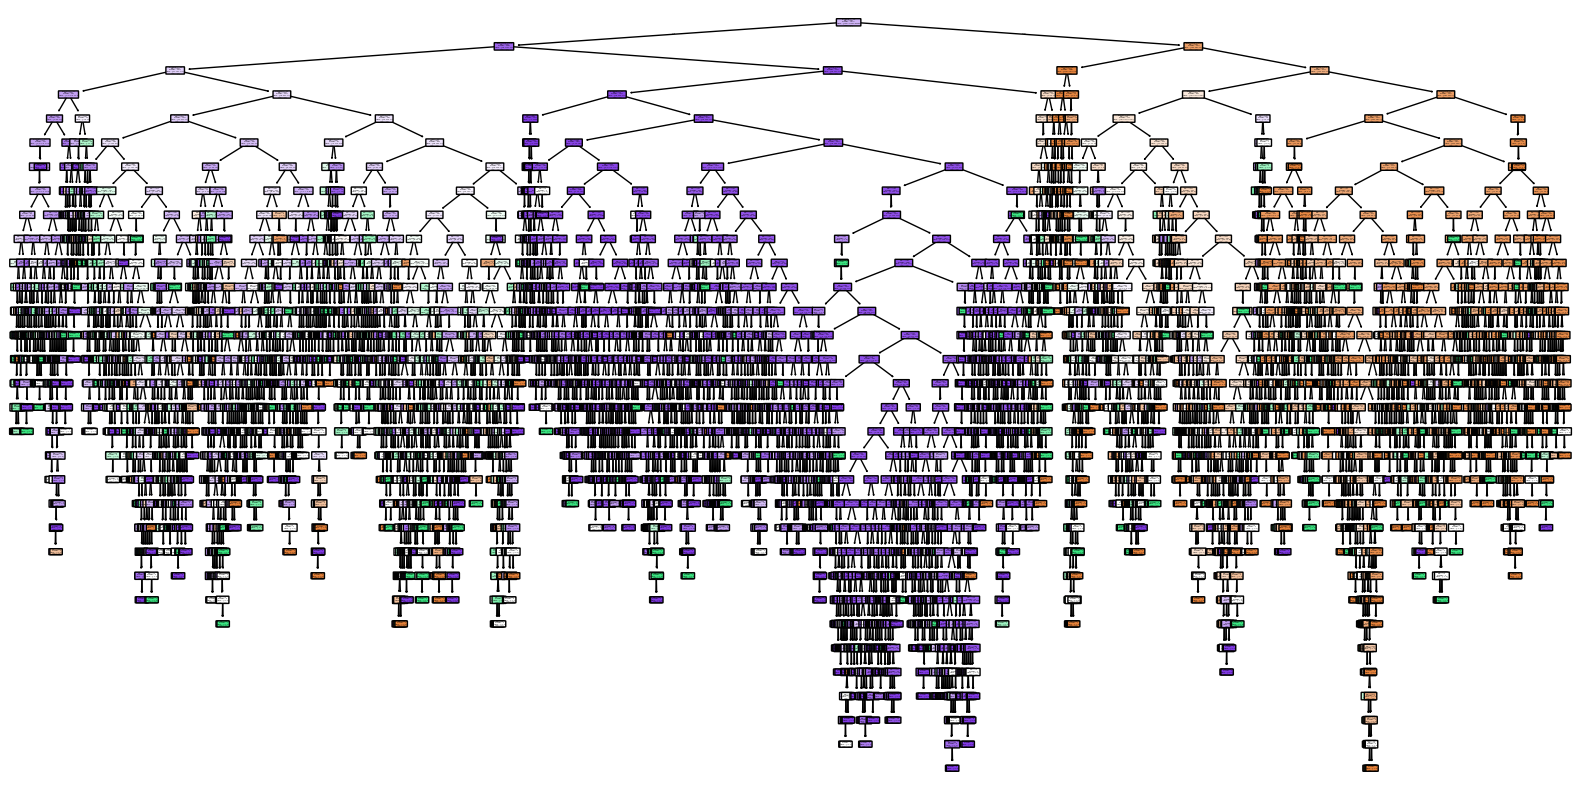

In [19]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    modelo,
    filled=True,
    feature_names=base.columns[:-1],
    class_names=True,
    rounded=True
)

plt.show()

In [ ]:
import joblib

modelo = joblib.load(
    "/content/drive/MyDrive/Colab Notebooks/Curso completo inteligencia artificial/3.Algoritmos de Machine Learning/DecisionTree/decision_tree.pkl"
)

print("Modelo carregado com sucesso!")
print(modelo)

In [ ]:
import joblib

modelo = joblib.load(
    "/content/drive/MyDrive/Colab Notebooks/Curso completo inteligencia artificial/3.Algoritmos de Machine Learning/DecisionTree/decision_tree.pkl"
)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Criar cópia da base
base2 = base.copy()

# Converter colunas texto para números
for coluna in base2.columns:
    if base2[coluna].dtype == 'object':
        encoder = LabelEncoder()
        base2[coluna] = encoder.fit_transform(base2[coluna])

# Separar atributos e classe
X = base2.iloc[:, :-1]
y = base2.iloc[:, -1]

# Separar treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=1
)

# Criar modelo
modelo = DecisionTreeClassifier()

# Treinar
modelo.fit(X_treino, y_treino)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


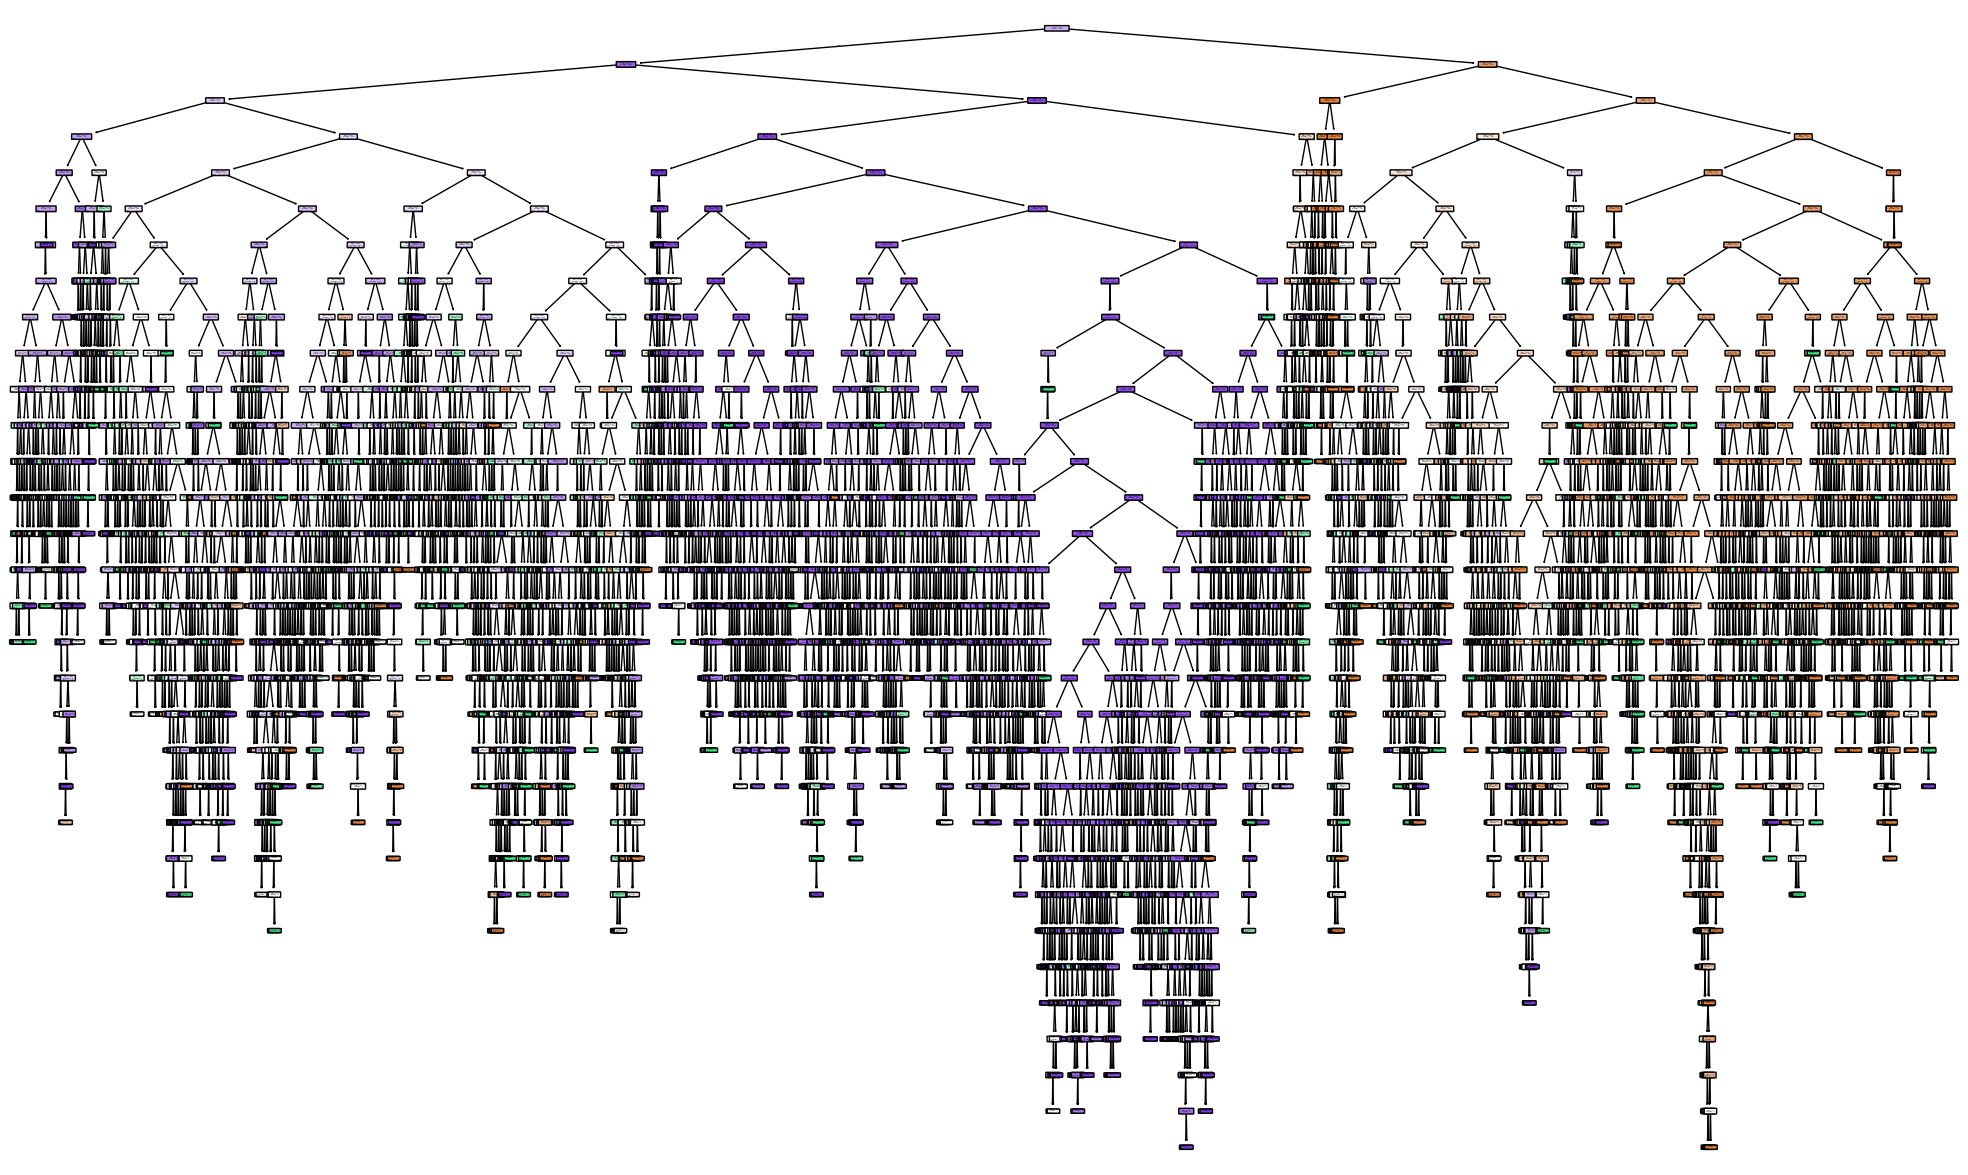

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25,15))

plot_tree(
    modelo,
    filled=True,
    feature_names=X.columns,
    rounded=True
)

plt.show()